# Hyperparameter Tuning, GridSearchCV & Cross-Validation

## 1. The Problem — Why We Need Cross-Validation

Throughout this course, we have been evaluating models using a single **train-test split** — training on 80% of the data and testing on 20%. This is simple and fast, but it has a serious flaw:

**The test score depends on which specific samples ended up in the test set.**

If we got "lucky" and the test set happened to contain easy-to-classify samples, our accuracy looks great. If the split was "unlucky," the score is worse. We are drawing conclusions from a **single roll of the dice**.

Even worse: if we try many hyperparameters and pick the one with the best test score, we are **overfitting to the test set**. The model is not truly generalizing — it is just performing well on that particular 20% split.

### The Three-Way Problem

We actually need data for **three** purposes:
1. **Training** — to fit the model
2. **Validation** — to tune hyperparameters and select the best model
3. **Testing** — to estimate how the final model will perform on truly unseen data

If we use the test set for validation (hyperparameter tuning), it is no longer a fair estimate of real-world performance. But splitting into three sets (train/validation/test) wastes precious data — especially with small datasets.

**Cross-validation** elegantly solves this problem.

## 2. What is K-Fold Cross-Validation?

K-Fold Cross-Validation works like this:

1. **Split** the training data into $K$ equal-sized parts ("folds"). A common choice is $K=5$.

2. **Iterate**: For each fold $i$ from 1 to $K$:
   - Use fold $i$ as the **validation set**
   - Use the remaining $K-1$ folds as the **training set**
   - Train the model and evaluate on fold $i$

3. **Average** the $K$ validation scores to get the **cross-validated score**.

With 5-fold CV, every sample is used for validation exactly once and for training four times. This gives us a much more reliable performance estimate than a single split.

### Why K=5 or K=10?

- **K=5** — Good balance between computation and reliability. Most common default.
- **K=10** — More folds = slightly more reliable estimate but slower.
- **K=n (Leave-One-Out)** — Each sample is a fold. Maximum data usage but very slow and high variance.

### Stratified K-Fold

For classification, we should use **Stratified** K-Fold, which ensures that each fold preserves the class proportions of the original dataset. Without stratification, a fold might accidentally get too many samples of one class and too few of another.

## 3. What are Hyperparameters?

Let us be very clear about the distinction between **parameters** and **hyperparameters**:

- **Parameters** are learned by the model during training. Examples: coefficients in Linear Regression, weights in a neural network, split thresholds in a Decision Tree. You do not set these — the algorithm finds them.

- **Hyperparameters** are set by **you** before training begins. They control the model's behavior, complexity, and learning process. Examples:
  - `max_depth` in Decision Tree
  - `n_estimators` in Random Forest
  - `C` and `gamma` in SVM
  - `alpha` in Ridge/Lasso
  - `n_components` in PCA
  - `learning_rate` in Gradient Boosting

Choosing the right hyperparameters can make the difference between a mediocre model and an excellent one. The process of systematically finding the best hyperparameters is called **hyperparameter tuning**.

## 4. GridSearchCV — Exhaustive Search

`GridSearchCV` combines cross-validation with a **grid search** over hyperparameters. Here is how it works:

1. You define a **grid** of hyperparameter values to try. For example:
   - `C`: [0.1, 1, 10, 100]
   - `gamma`: [0.01, 0.1, 1]

2. GridSearchCV tries **every combination** in the grid:
   - (C=0.1, gamma=0.01), (C=0.1, gamma=0.1), (C=0.1, gamma=1),
   - (C=1, gamma=0.01), ... and so on.

3. For each combination, it runs **K-fold cross-validation** and computes the average validation score.

4. It picks the combination with the **best average score**.

5. Finally, it **refits** the best model on the entire training set.

In our example: 4 values of C × 3 values of gamma = 12 combinations. With 5-fold CV, that is 12 × 5 = **60 model fits**. This is why grid search can be slow — it is exhaustive.

### RandomizedSearchCV — Faster Alternative

When the grid is very large, `RandomizedSearchCV` samples a fixed number of random combinations instead of trying all of them. It is much faster and often finds results nearly as good as the full grid search.

---

## 5. Setup and Imports

**Task:** Import all required libraries.

In [1]:
# Import numpy, pandas, matplotlib.pyplot, seaborn

# From sklearn.model_selection import (
#     train_test_split, cross_val_score, StratifiedKFold,
#     GridSearchCV, RandomizedSearchCV
# )

# From sklearn.preprocessing import StandardScaler

# From sklearn.linear_model import LogisticRegression
# From sklearn.svm import SVC
# From sklearn.tree import DecisionTreeClassifier
# From sklearn.ensemble import RandomForestClassifier

# From sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# From sklearn.datasets import load_breast_cancer

# Import time for benchmarking



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.datasets import load_breast_cancer



---

## 6. Loading and Preparing Data

**Task:** Load the Breast Cancer dataset, split into train/test, and scale.

In [3]:
# Load Breast Cancer dataset

# Split: test_size=0.2, random_state=42, stratify=y

# Scale with StandardScaler (fit on train, transform both)

# Print shapes

cancer = load_breast_cancer(as_frame = True)
X = cancer.data
y = cancer.target


X_train, X_test, y_train, y_test = train_test_split(
    
    X, y, random_state=42, stratify=y
)



print(f"Training: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test:     {X_test.shape[0]} samples (held out until final evaluation)")

Training: 426 samples, 30 features
Test:     143 samples (held out until final evaluation)


---

## 7. Cross-Validation in Action — `cross_val_score`

Before we do any hyperparameter tuning, let us first see cross-validation itself in action. `cross_val_score` takes a model, the training data, and the number of folds, then returns a score for each fold.

This gives us a **distribution** of scores rather than a single number — much more informative.

**Task:** Run 5-fold cross-validation on Logistic Regression and examine the fold-by-fold scores.

In [5]:
# Create a LogisticRegression(random_state=42, max_iter=5000)

# Run cross_val_score with cv=5 and scoring='accuracy'
# Use X_train_sc, y_train (NOT the test set)

# Print each fold's score

# Print the mean and standard deviation of the scores

# Also run with scoring='roc_auc' and print those results

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter= 5000)

cv_scores = cross_val_score(lr, X_train_sc, y_train, cv = 5, scoring= 'accuracy')
cv_auc = cross_val_score(lr, X_train_sc, y_train, cv = 5, scoring= 'roc_auc')



print("5-Fold Cross-Validation — Logistic Regression")
print("=" * 50)
print("  Accuracy per fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"    Fold {i}: {score:.4f}")
print(f"  Mean Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"\n  AUC per fold:")
for i, score in enumerate(cv_auc, 1):
    print(f"    Fold {i}: {score:.4f}")
print(f"  Mean AUC:      {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

5-Fold Cross-Validation — Logistic Regression
  Accuracy per fold:
    Fold 1: 0.9767
    Fold 2: 0.9882
    Fold 3: 0.9529
    Fold 4: 0.9647
    Fold 5: 0.9765
  Mean Accuracy: 0.9718 ± 0.0120

  AUC per fold:
    Fold 1: 0.9936
    Fold 2: 0.9994
    Fold 3: 0.9794
    Fold 4: 0.9971
    Fold 5: 0.9976
  Mean AUC:      0.9934 ± 0.0073


**What to observe:** You will get 5 accuracy values — one for each fold. They will be similar but not identical, showing the variability in model performance across different data subsets. The **mean** is our best estimate of model performance. The **standard deviation** tells us how stable the model is — a low std means the model performs consistently.

### 7.1 Comparing Models with Cross-Validation

Cross-validation is the right way to compare models. Instead of relying on a single test score, we compare the **cross-validated mean scores** and their variability.

**Task:** Compare all four classifiers using 5-fold CV.

In [11]:
# Define models:
#   'Logistic Regression': LogisticRegression(random_state=42, max_iter=5000) — use scaled data
#   'SVM (RBF)': SVC(random_state=42, probability=True) — use scaled data
#   'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42) — use unscaled data
#   'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42) — use unscaled data

# For each model:
#   Run cross_val_score with cv=5, scoring='accuracy'
#   Store mean and std

# Display comparison table: Model, Mean CV Accuracy, Std

# Create a box plot of the CV scores for visual comparison
# figsize=(10, 6)

models_cv = {
    'Logistic Reg': (LogisticRegression(random_state=42, max_iter = 5000), X_train_sc),
    'SVM (RBF)' :  (SVC(random_state=42, probability=True), X_train_sc),
    'Decision Tree': (DecisionTreeClassifier(max_depth = 5, random_state=42), X_train),
    'Random _forest':(RandomForestClassifier(n_estimators=100, random_state=42), X_train)
}

cv_results_all = {}
for name,(Model,X_data) in models_cv.items():
    scores = cross_val_score(Model, X_data, y_train, cv =5, scoring='accuracy')
    cv_results_all[name] = scores
    
    print(f"{name} {scores.mean():.2f}   |    {scores.std():.2f}")
    

Logistic Reg 0.97   |    0.01
SVM (RBF) 0.96   |    0.02
Decision Tree 0.93   |    0.02
Random _forest 0.96   |    0.02


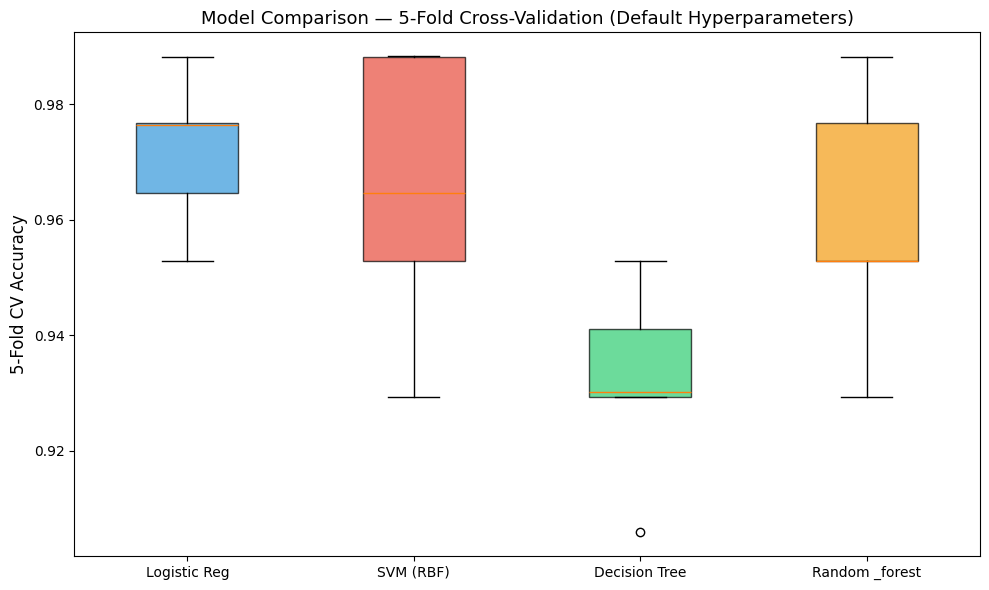

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

box_data = [cv_results_all[name] for name in cv_results_all]
bp = ax.boxplot(box_data, labels=list(cv_results_all.keys()), patch_artist=True)

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)
ax.set_title('Model Comparison — 5-Fold Cross-Validation (Default Hyperparameters)', fontsize=13)
plt.tight_layout()
plt.show()

**What to observe:** The box plot gives a powerful visual. A model with a higher median and tighter box (less spread) is more reliable. If two models have overlapping boxes, the difference between them is not statistically significant.

---

## 8. GridSearchCV — Tuning SVM

SVM has two critical hyperparameters: `C` (regularization) and `gamma` (kernel width). Let us use GridSearchCV to find the best combination.

We define a grid of values to try, and GridSearchCV exhaustively evaluates every combination using cross-validation.

**Task:** Define a parameter grid and run GridSearchCV for SVM.

In [13]:
# Define the parameter grid:
# param_grid = {
#     'C': [0.01, 0.1, 1, 10, 100],
#     'gamma': ['scale', 0.01, 0.1, 1],
#     'kernel': ['rbf']
# }

# Create GridSearchCV:
#   estimator = SVC(probability=True, random_state=42)
#   param_grid = param_grid
#   cv = 5 (5-fold stratified cross-validation)
#   scoring = 'accuracy'
#   verbose = 1 (to see progress)
#   n_jobs = -1 (use all CPU cores)
#   return_train_score = True

# Fit on X_train_sc, y_train

# Print:
#   Total combinations tried
#   Best parameters: grid_search.best_params_
#   Best CV score: grid_search.best_score_

svm_hyper_para_grid = {
    'C' : [0.01,0.1,10,100],
    'gamma': ['scale', 0.01,0.1,1],
    'kernel': ['rbf']
}

svm_grid = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid= svm_hyper_para_grid,
    cv = 5,
    scoring= 'accuracy',
    n_jobs = -1,
    return_train_score=True,
    
)

t_start = time.time()
svm_grid.fit(X_train_sc, y_train)
svm_time = time.time() - t_start

total_combos = len(svm_hyper_para_grid['C'] * len(svm_hyper_para_grid['gamma']))

print("=" * 55)
print("  GRIDSEARCHCV — SVM (RBF)")
print("=" * 55)
print(f"  Combinations tried: {total_combos}")
print(f"  Total model fits:   {total_combos * 5} (5-fold CV)")
print(f"  Time taken:         {svm_time:.1f} seconds")
print(f"  Best params:        {svm_grid.best_params_}")
print(f"  Best CV accuracy:   {svm_grid.best_score_:.4f}")
print("=" * 55)


  GRIDSEARCHCV — SVM (RBF)
  Combinations tried: 16
  Total model fits:   80 (5-fold CV)
  Time taken:         5.8 seconds
  Best params:        {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
  Best CV accuracy:   0.9671


**What to observe:** GridSearchCV has tried every combination (4 × 4 = 16 combinations, each evaluated with 5-fold CV = 80 total model fits). The `best_params_` shows the winning combination, and `best_score_` is the average CV accuracy for that combination.

### 8.1 Examining All Results

GridSearchCV stores detailed results for every combination in `cv_results_`. Let us examine them.

**Task:** Create a DataFrame of all results and visualize the grid.

In [14]:
# Convert grid_search.cv_results_ to a DataFrame

# Select columns: 'param_C', 'param_gamma', 'mean_test_score',
#                  'std_test_score', 'mean_train_score', 'rank_test_score'

# Sort by rank_test_score

# Print the top 10 combinations

results_df = pd.DataFrame(svm_grid.cv_results_)

print("Top 10 Combinations:")
top10 = results_df[['param_C', 'param_gamma', 'mean_test_score',
                     'std_test_score', 'mean_train_score', 'rank_test_score']]\
    .sort_values('rank_test_score').head(10)
print(top10.to_string(index=False))


Top 10 Combinations:
 param_C param_gamma  mean_test_score  std_test_score  mean_train_score  rank_test_score
    10.0        0.01         0.967114        0.011572          0.986502                1
   100.0        0.01         0.964788        0.022323          0.995306                2
    10.0       scale         0.960055        0.020557          0.993547                3
     0.1         0.1         0.952996        0.014968          0.973592                4
   100.0       scale         0.950725        0.020179          1.000000                5
   100.0         0.1         0.948372        0.005600          1.000000                6
     0.1        0.01         0.948317        0.012111          0.953050                7
     0.1       scale         0.948290        0.017696          0.959507                8
    10.0         0.1         0.941341        0.007184          1.000000                9
    10.0           1         0.631464        0.004891          1.000000               10


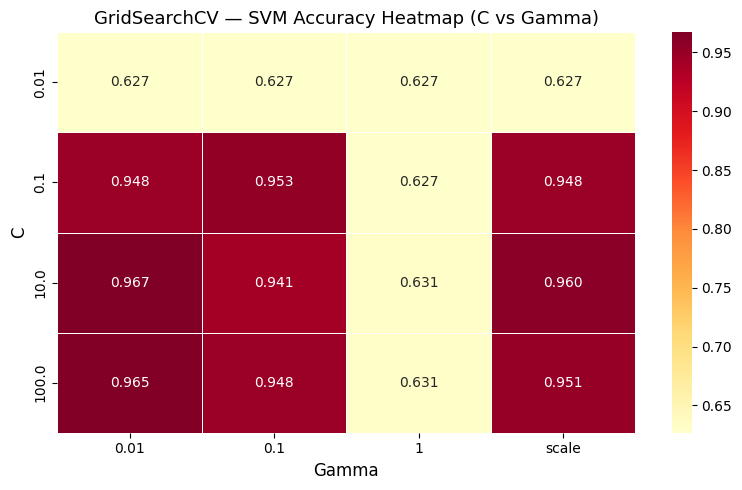

In [15]:

# Create a heatmap: C vs gamma, color = mean_test_score
# Use pivot_table to reshape the data
# figsize=(8, 5)
# Add title: 'GridSearchCV — SVM Accuracy Heatmap'
# Show the plot

pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5)
plt.title('GridSearchCV — SVM Accuracy Heatmap (C vs Gamma)', fontsize=13)
plt.xlabel('Gamma', fontsize=12)
plt.ylabel('C', fontsize=12)
plt.tight_layout()
plt.show()

**What to observe:** The heatmap reveals the interaction between C and gamma. There is typically a "sweet spot" region where accuracy is highest. Very low C (too much regularization) and very high gamma (overfitting) both produce poor results. The best combination balances these forces.

### 8.2 Evaluating the Best Model on the Test Set

GridSearchCV automatically refits the best model on the entire training set. We can access it via `grid_search.best_estimator_` and evaluate on the test set.

**Important:** We only touch the test set **once** — now, with the final tuned model. This gives us an unbiased estimate of real-world performance.

**Task:** Evaluate the best SVM on the test set.

In [16]:
# Get the best model: grid_search.best_estimator_

# Predict on X_test_sc

# Compute test accuracy and AUC

# Print:
#   Best params
#   Best CV score (from tuning)
#   Test accuracy (on held-out test set)
#   Test AUC

# Print classification report



best_svm = svm_grid.best_estimator_

y_pred_svm = best_svm.predict(X_test_sc)
y_prob_svm = best_svm.predict_proba(X_test_sc)[:, 1]

svm_test_acc = accuracy_score(y_test, y_pred_svm)
svm_test_auc = roc_auc_score(y_test, y_prob_svm)

print("=" * 55)
print("  TUNED SVM — Final Test Evaluation")
print("=" * 55)
print(f"  Best Params:    {svm_grid.best_params_}")
print(f"  Best CV Score:  {svm_grid.best_score_:.4f}")
print(f"  Test Accuracy:  {svm_test_acc:.4f}")
print(f"  Test AUC:       {svm_test_auc:.4f}")
print(f"  CV-Test Gap:    {svm_grid.best_score_ - svm_test_acc:.4f}")
print("=" * 55)
print(f"\n{classification_report(y_test, y_pred_svm, target_names=['Malignant', 'Benign'])}")


  TUNED SVM — Final Test Evaluation
  Best Params:    {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
  Best CV Score:  0.9671
  Test Accuracy:  0.9790
  Test AUC:       0.9987
  CV-Test Gap:    -0.0119

              precision    recall  f1-score   support

   Malignant       0.96      0.98      0.97        53
      Benign       0.99      0.98      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



**What to observe:** The test accuracy should be close to the best CV score. If the test accuracy is much lower than the CV score, we may have overfit to the CV splits (unlikely with proper methodology). If it is close, our tuning was successful and the model generalizes well.

---

## 9. GridSearchCV — Tuning Random Forest

Let us apply the same approach to Random Forest, which has different hyperparameters.

**Task:** Define a grid for Random Forest and run GridSearchCV.

In [17]:
# Define the parameter grid:
# rf_param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [3, 5, 10, None],
#     'max_features': ['sqrt', 'log2'],
#     'min_samples_leaf': [1, 2, 5]
# }

# Create GridSearchCV with RandomForestClassifier(random_state=42)
# cv=5, scoring='accuracy', n_jobs=-1

# Fit on X_train, y_train (unscaled — RF does not need scaling)

# Print: total combinations, best params, best CV score

# Evaluate on test set: accuracy and AUC



rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True,
    verbose=0
)

t_start = time.time()
rf_grid.fit(X_train, y_train)
rf_time = time.time() - t_start

total = 3 * 4 * 2 * 3
print("=" * 55)
print("  GRIDSEARCHCV — Random Forest")
print("=" * 55)
print(f"  Combinations:   {total}")
print(f"  Total fits:     {total * 5}")
print(f"  Time:           {rf_time:.1f} seconds")
print(f"  Best params:    {rf_grid.best_params_}")
print(f"  Best CV score:  {rf_grid.best_score_:.4f}")
print("=" * 55)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
rf_test_acc = accuracy_score(y_test, y_pred_rf)
rf_test_auc = roc_auc_score(y_test, y_prob_rf)

print(f"  Test Accuracy:  {rf_test_acc:.4f}")
print(f"  Test AUC:       {rf_test_auc:.4f}")

  GRIDSEARCHCV — Random Forest
  Combinations:   72
  Total fits:     360
  Time:           15.8 seconds
  Best params:    {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 100}
  Best CV score:  0.9647
  Test Accuracy:  0.9580
  Test AUC:       0.9929


**What to observe:** Random Forest has more hyperparameters, so the grid is larger (3 × 4 × 2 × 3 = 72 combinations × 5 folds = 360 fits). This takes longer but gives a thorough search. The best Random Forest may outperform the best SVM — or vice versa. The point is that both models are now **fairly compared** after proper tuning.

---

## 10. RandomizedSearchCV — Faster Tuning

When the grid is very large, GridSearchCV becomes impractical. `RandomizedSearchCV` instead samples a fixed number of random hyperparameter combinations from specified distributions.

**Task:** Use RandomizedSearchCV to tune Random Forest with a broader search space.

In [18]:
# From scipy.stats import randint, uniform

# Define distributions (not fixed lists):
# rf_dist = {
#     'n_estimators': randint(50, 500),
#     'max_depth': [3, 5, 7, 10, 15, 20, None],
#     'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
#     'min_samples_leaf': randint(1, 10),
#     'min_samples_split': randint(2, 20)
# }

# Create RandomizedSearchCV:
#   estimator = RandomForestClassifier(random_state=42)
#   param_distributions = rf_dist
#   n_iter = 50 (try 50 random combinations)
#   cv = 5, scoring = 'accuracy', random_state = 42, n_jobs = -1

# Fit on X_train, y_train

# Print: best params, best CV score

# Evaluate on test set

# Compare time with GridSearchCV




from scipy.stats import randint

rf_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'min_samples_leaf': randint(1, 10),
    'min_samples_split': randint(2, 20)
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

t_start = time.time()
rf_random.fit(X_train, y_train)
rand_time = time.time() - t_start

best_rf_rand = rf_random.best_estimator_
y_pred_rfr = best_rf_rand.predict(X_test)
y_prob_rfr = best_rf_rand.predict_proba(X_test)[:, 1]
rfr_test_acc = accuracy_score(y_test, y_pred_rfr)
rfr_test_auc = roc_auc_score(y_test, y_prob_rfr)

print("=" * 58)
print("  RANDOMIZEDSEARCHCV — Random Forest")
print("=" * 58)
print(f"  Combinations sampled: 50")
print(f"  Total fits:           {50 * 5}")
print(f"  Time:                 {rand_time:.1f} seconds")
print(f"  Best params:          {rf_random.best_params_}")
print(f"  Best CV score:        {rf_random.best_score_:.4f}")
print(f"  Test Accuracy:        {rfr_test_acc:.4f}")
print(f"  Test AUC:             {rfr_test_auc:.4f}")
print("=" * 58)

print(f"\n  Comparison with GridSearchCV:")
print(f"  {'Method':<22} {'CV Score':>10} {'Test Acc':>10} {'Time (s)':>10}")
print(f"  {'-'*22} {'-'*10} {'-'*10} {'-'*10}")
print(f"  {'GridSearchCV':<22} {rf_grid.best_score_:>10.4f} {rf_test_acc:>10.4f} {rf_time:>10.1f}")
print(f"  {'RandomizedSearchCV':<22} {rf_random.best_score_:>10.4f} {rfr_test_acc:>10.4f} {rand_time:>10.1f}")


  RANDOMIZEDSEARCHCV — Random Forest
  Combinations sampled: 50
  Total fits:           250
  Time:                 12.0 seconds
  Best params:          {'max_depth': 5, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 162}
  Best CV score:        0.9601
  Test Accuracy:        0.9580
  Test AUC:             0.9931

  Comparison with GridSearchCV:
  Method                   CV Score   Test Acc   Time (s)
  ---------------------- ---------- ---------- ----------
  GridSearchCV               0.9647     0.9580       15.8
  RandomizedSearchCV         0.9601     0.9580       12.0


**What to observe:** RandomizedSearchCV explores a broader space (continuous distributions instead of fixed grids) with fewer evaluations (50 vs 72+). The best score is often very close to GridSearchCV's result — sometimes even better because it can explore values that a grid would miss. The training time should be noticeably shorter.

---

## 11. Tuning Logistic Regression

Let us also tune Logistic Regression for completeness. The key hyperparameters are `C` (regularization strength) and `penalty` (L1 vs L2).

**Task:** Run GridSearchCV for Logistic Regression.

In [19]:
# # Define the parameter grid:
# # lr_param_grid = {
# #     'C': [0.001, 0.01, 0.1, 1, 10, 100],
# #     'penalty': ['l1', 'l2'],
# #     'solver': ['liblinear']  # supports both L1 and L2
# # }

# # Run GridSearchCV on scaled data

# # Print best params, best CV score, test accuracy, AUC

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=5000),
    param_grid=lr_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

lr_grid.fit(X_train_sc, y_train)

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_sc)
y_prob_lr = best_lr.predict_proba(X_test_sc)[:, 1]
lr_test_acc = accuracy_score(y_test, y_pred_lr)
lr_test_auc = roc_auc_score(y_test, y_prob_lr)

print("=" * 55)
print("  GRIDSEARCHCV — Logistic Regression")
print("=" * 55)
print(f"  Best params:    {lr_grid.best_params_}")
print(f"  Best CV score:  {lr_grid.best_score_:.4f}")
print(f"  Test Accuracy:  {lr_test_acc:.4f}")
print(f"  Test AUC:       {lr_test_auc:.4f}")
print("=" * 55)

  GRIDSEARCHCV — Logistic Regression
  Best params:    {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
  Best CV score:  0.9789
  Test Accuracy:  0.9860
  Test AUC:       0.9971


---

## 12. Grand Comparison — All Tuned Models

Now let us compare all four models after proper hyperparameter tuning. This is the fairest comparison possible — each model has been given the opportunity to find its best configuration.

**Task:** Collect the best test scores from all tuned models and compare.

In [20]:
# # Collect results from all GridSearchCV runs:
# #   For each model: name, best params, best CV score, test accuracy, test AUC

# # Display comparison table sorted by test accuracy

# # Print the overall winner

# # Compare tuned vs default performance
# # (use the default scores from Section 7.1 as baseline)


grand_results = [
    {
        'Model': 'Logistic Regression',
        'Best Params': str(lr_grid.best_params_),
        'Best CV Score': round(lr_grid.best_score_, 4),
        'Test Accuracy': round(lr_test_acc, 4),
        'Test AUC': round(lr_test_auc, 4)
    },
    {
        'Model': 'SVM (RBF)',
        'Best Params': str(svm_grid.best_params_),
        'Best CV Score': round(svm_grid.best_score_, 4),
        'Test Accuracy': round(svm_test_acc, 4),
        'Test AUC': round(svm_test_auc, 4)
    },
    {
        'Model': 'Random Forest (Grid)',
        'Best Params': str(rf_grid.best_params_),
        'Best CV Score': round(rf_grid.best_score_, 4),
        'Test Accuracy': round(rf_test_acc, 4),
        'Test AUC': round(rf_test_auc, 4)
    },
    {
        'Model': 'Random Forest (Random)',
        'Best Params': str(rf_random.best_params_),
        'Best CV Score': round(rf_random.best_score_, 4),
        'Test Accuracy': round(rfr_test_acc, 4),
        'Test AUC': round(rfr_test_auc, 4)
    }
]

grand_df = pd.DataFrame(grand_results)
display_df = grand_df[['Model', 'Best CV Score', 'Test Accuracy', 'Test AUC']]\
    .sort_values('Test Accuracy', ascending=False)

print("=" * 62)
print("  GRAND COMPARISON — All Tuned Models")
print("=" * 62)
print(display_df.to_string(index=False))
print("=" * 62)

winner = display_df.iloc[0]
print(f"\n  Winner (Accuracy): {winner['Model']} — {winner['Test Accuracy']}")

print("\n  Best Hyperparameters for each model:")
for _, row in grand_df.iterrows():
    print(f"    {row['Model']}: {row['Best Params']}")

  GRAND COMPARISON — All Tuned Models
                 Model  Best CV Score  Test Accuracy  Test AUC
   Logistic Regression         0.9789          0.986    0.9971
             SVM (RBF)         0.9671          0.979    0.9987
  Random Forest (Grid)         0.9647          0.958    0.9929
Random Forest (Random)         0.9601          0.958    0.9931

  Winner (Accuracy): Logistic Regression — 0.986

  Best Hyperparameters for each model:
    Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
    SVM (RBF): {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
    Random Forest (Grid): {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 100}
    Random Forest (Random): {'max_depth': 5, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 162}


**What to observe:** After tuning, some models may have improved significantly (especially SVM and Decision Tree, which are sensitive to hyperparameters), while others may have changed little (Random Forest with defaults is usually already close to optimal). The gap between models may shrink after tuning — proper tuning levels the playing field.

---

## 13. Best Practices and Common Pitfalls

### Do:
- Always use **cross-validation** for hyperparameter tuning, never the test set
- Use **stratified** K-fold for classification tasks
- Start with a **coarse grid**, then refine around the best region
- Use `RandomizedSearchCV` for large search spaces
- Report **both** CV score and test score
- Scale features **inside** the CV pipeline (we will cover this advanced pattern in a later lecture)

### Don't:
- Do not tune hyperparameters on the test set — that defeats the purpose of having a test set
- Do not compare models using a single train-test split — use CV
- Do not use too many folds on small datasets (each fold becomes too small)
- Do not forget to set `random_state` for reproducibility
- Do not blindly trust the best CV score — always check test set performance as a sanity check

### The Correct Workflow

1. Split data into **train** and **test** (test is untouched until the very end)
2. Use **cross-validation on the training set** to tune hyperparameters
3. Select the best model based on CV scores
4. Evaluate the final model **once** on the test set
5. Report the test score as the expected real-world performance

---

## 14. Summary and Key Takeaways

**Cross-Validation:**
- Splits training data into $K$ folds, trains on $K-1$, validates on the held-out fold
- Repeats $K$ times and averages → more reliable than a single split
- Use `StratifiedKFold` for classification to preserve class proportions

**Hyperparameter Tuning:**

| Method | How It Works | When to Use |
|--------|-------------|-------------|
| `GridSearchCV` | Tries every combination | Small/medium grids |
| `RandomizedSearchCV` | Samples random combinations | Large search spaces |

**Key Parameters of GridSearchCV:**
- `param_grid` — dictionary of hyperparameters and values to try
- `cv` — number of folds (default 5)
- `scoring` — metric to optimize ('accuracy', 'roc_auc', 'f1', etc.)
- `n_jobs=-1` — use all CPU cores for parallel computation
- `return_train_score=True` — also compute training scores (for overfitting diagnosis)

**Key Outputs:**
- `best_params_` — the winning hyperparameter combination
- `best_score_` — the best cross-validated score
- `best_estimator_` — the model refitted on all training data with best params
- `cv_results_` — detailed results for every combination

**What comes next:** Advanced topics — feature engineering, more ensemble methods (Gradient Boosting), and deploying models.